In [1]:
# Install Detectron2
!pip install -q torch torchvision torchaudio
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.7 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installe

In [2]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2 import model_zoo
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog


In [3]:
cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)




In [4]:
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.MODEL.WEIGHTS = "/kaggle/input/faster-rcnn-fire-smoke-detection/output_faster_rcnn/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda"

predictor = DefaultPredictor(cfg)

In [6]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog

# Register datasets (needed even for inference)
register_coco_instances(
    "fire_test",
    {},
    "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_coco/test.json",
    "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_subset/test/images"
)

MetadataCatalog.get("fire_test").thing_classes = ["fire", "smoke"]

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")
)

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 2
cfg.MODEL.WEIGHTS = (
    "/kaggle/input/faster-rcnn-fire-smoke-detection/output_faster_rcnn/model_final.pth"
)
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("fire_test",)

predictor = DefaultPredictor(cfg)


SyntaxError: invalid syntax (3956292280.py, line 2)

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


(-0.5, 639.5, 639.5, -0.5)

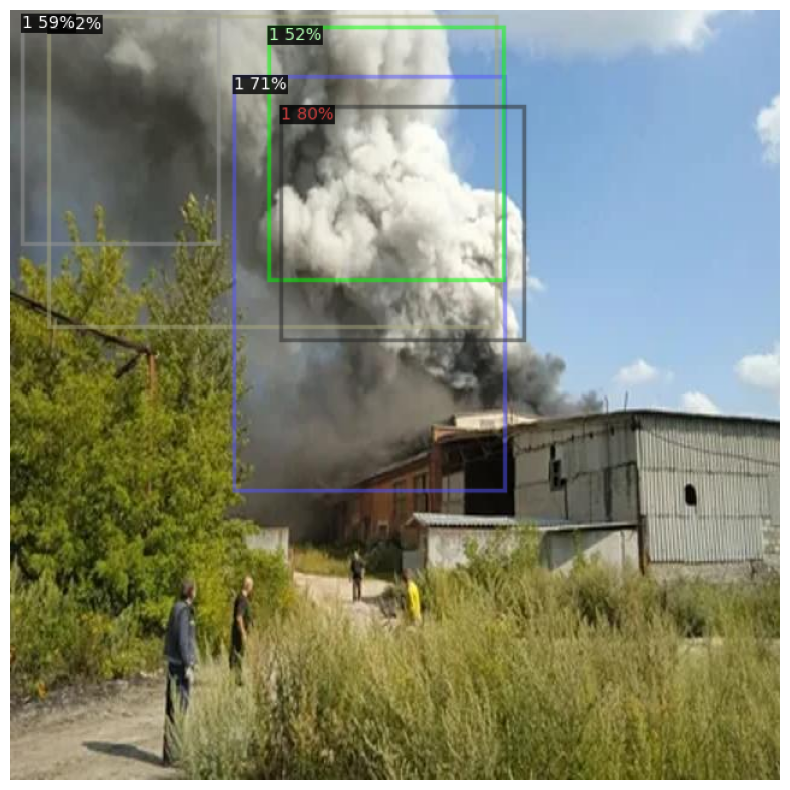

In [9]:
import cv2
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer

img_path = (
"/kaggle/input/faster-rcnn-fire-smoke-detection/fire_subset/test/images/-861369_png.rf.5ff57d98a92fe49b68645b61eaf73212.jpg"
)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

outputs = predictor(img)

v = Visualizer(img, scale=1.0)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(10,10))
plt.imshow(out.get_image())
plt.axis("off")


In [12]:
import json
import os

def fix_coco_info(json_path):
    with open(json_path, "r") as f:
        coco = json.load(f)

    if "info" not in coco:
        coco["info"] = {
            "description": "Fire/Smoke Detection Dataset",
            "version": "1.0",
            "year": 2024,
            "contributor": "Kaggle Notebook",
            "date_created": "2024-01-01"
        }

    with open(json_path, "w") as f:
        json.dump(coco, f)

# PATCH all three splits
BASE = "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_coco"

fix_coco_info(f"{BASE}/train.json")
fix_coco_info(f"{BASE}/val.json")
fix_coco_info(f"{BASE}/test.json")

print("✅ COCO JSON files patched with info field")


OSError: [Errno 30] Read-only file system: '/kaggle/input/faster-rcnn-fire-smoke-detection/fire_coco/train.json'

In [11]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

cfg.DATASETS.TEST = ("fire_test",)
cfg.MODEL.WEIGHTS = "/kaggle/input/faster-rcnn-fire-smoke-detection/output_faster_rcnn/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

evaluator = COCOEvaluator(
    "fire_test",
    cfg,
    False,
    output_dir="./eval"
)

test_loader = build_detection_test_loader(cfg, "fire_test")

results = inference_on_dataset(
    predictor.model,
    test_loader,
    evaluator
)

results


COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



KeyError: 'info'

In [13]:
import os
import shutil

SRC = "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_coco"
DST = "/kaggle/working/fire_coco"

os.makedirs(DST, exist_ok=True)

for f in ["train.json", "val.json", "test.json"]:
    shutil.copy(
        os.path.join(SRC, f),
        os.path.join(DST, f)
    )

print("✅ COCO JSON files copied to /kaggle/working")


✅ COCO JSON files copied to /kaggle/working


In [14]:
import json

def fix_coco_info(json_path):
    with open(json_path, "r") as f:
        coco = json.load(f)

    if "info" not in coco:
        coco["info"] = {
            "description": "Fire/Smoke Detection Dataset",
            "version": "1.0",
            "year": 2024,
            "contributor": "Kaggle Notebook",
            "date_created": "2024-01-01"
        }

    with open(json_path, "w") as f:
        json.dump(coco, f)

BASE = "/kaggle/working/fire_coco"

fix_coco_info(f"{BASE}/train.json")
fix_coco_info(f"{BASE}/val.json")
fix_coco_info(f"{BASE}/test.json")

print("✅ COCO JSON files patched with info field")


✅ COCO JSON files patched with info field


In [16]:
from detectron2.data import DatasetCatalog, MetadataCatalog

for name in ["fire_train", "fire_val", "fire_test"]:
    if name in DatasetCatalog.list():
        DatasetCatalog.remove(name)
        MetadataCatalog.remove(name)

print("✅ Old dataset registrations cleared")


✅ Old dataset registrations cleared


In [17]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog

CLASSES = ["fire", "smoke"]

register_coco_instances(
    "fire_train",
    {},
    "/kaggle/working/fire_coco/train.json",
    "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_subset/train/images"
)

register_coco_instances(
    "fire_val",
    {},
    "/kaggle/working/fire_coco/val.json",
    "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_subset/val/images"
)

register_coco_instances(
    "fire_test",
    {},
    "/kaggle/working/fire_coco/test.json",
    "/kaggle/input/faster-rcnn-fire-smoke-detection/fire_subset/test/images"
)

MetadataCatalog.get("fire_train").thing_classes = CLASSES
MetadataCatalog.get("fire_val").thing_classes = CLASSES
MetadataCatalog.get("fire_test").thing_classes = CLASSES


In [18]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

cfg.DATASETS.TEST = ("fire_test",)
cfg.MODEL.WEIGHTS = "/kaggle/input/faster-rcnn-fire-smoke-detection/output_faster_rcnn/model_final.pth"

evaluator = COCOEvaluator("fire_test", cfg, False, output_dir="./eval")
test_loader = build_detection_test_loader(cfg, "fire_test")

results = inference_on_dataset(
    predictor.model,
    test_loader,
    evaluator
)

results


COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.

Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.225
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.503
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.148
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.170
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.153
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.263
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.241
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.312
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.314
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.199
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.217
 Average Recall     (AR) @[ IoU=0.50:0.

OrderedDict([('bbox',
              {'AP': 22.492252507484746,
               'AP50': 50.271099978987245,
               'AP75': 14.845923867002519,
               'APs': 16.999397098516692,
               'APm': 15.327426318430687,
               'APl': 26.27766161481186,
               'AP-fire': 30.442322809949246,
               'AP-smoke': 14.542182205020246})])